In [150]:
# aivietnam.ai - advertising
import numpy as np
# from numpy import genfromtxt
import matplotlib.pyplot as plt
import random
random.seed(0) # please do not remove this line
%matplotlib inline

def load_data_from_file(fileName = "advertising.csv"):
  data = np.genfromtxt(fileName, dtype=None, delimiter=',', skip_header=1)
  features_X = data[:, :3]
  sales_Y = data[:, 3]

  # **************** your code here ****************
  ones = np.ones((features_X.shape[0], 1))
  features_X = np.hstack((ones, features_X))

  return features_X, sales_Y


In [151]:
#Question 2
features_X, _ = load_data_from_file()
print(features_X[:5,:])

[[  1.  230.1  37.8  69.2]
 [  1.   44.5  39.3  45.1]
 [  1.   17.2  45.9  69.3]
 [  1.  151.5  41.3  58.5]
 [  1.  180.8  10.8  58.4]]


In [152]:
#Question 3
_, sales_Y = load_data_from_file()
print(sales_Y.shape)

(200,)


In [153]:

def create_individual(n=4, bound=10):
  return list((np.random.rand(n) - 0.5) * bound)

In [154]:
individual = create_individual()
print(individual)

[np.float64(4.916327411521557), np.float64(2.5721511232896543), np.float64(4.4994509887198255), np.float64(-3.548213289496729)]


In [155]:
def compute_loss(individual):
    theta = np.array(individual)
    y_hat = features_X.dot(theta)
    loss  = np.multiply((y_hat-sales_Y), (y_hat-sales_Y)).mean()
    return loss

def compute_fitness(individual):
    loss = compute_loss(individual)
    fitness_value = 1 / (loss + 1)
    return fitness_value

In [156]:
#question 4
features_X, sales_Y = load_data_from_file()
individual = [4.09, 4.82, 3.10, 4.02]
fitness_score = compute_fitness(individual)
print(fitness_score)

1.0185991537088997e-06


In [157]:
def crossover(individual1, individual2, crossover_rate = 0.9):
    ind1 = np.array(individual1)
    ind2 = np.array(individual2)
    n = len(ind1)
    mask = np.random.rand(n) <= crossover_rate

    ind1_new = ind1.copy()
    ind2_new = ind2.copy()
    ind1_new[mask], ind2_new[mask] = ind2[mask], ind1[mask]
    return ind1_new, ind2_new

In [158]:
#question 5
individual1 = [4.09, 4.82, 3.10, 4.02]
individual2 = [3.44, 2.57, -0.79, -2.41]

individual1, individual2 = crossover(individual1, individual2, 2.0)
print("individual1: ", individual1)
print("individual2: ", individual2)

individual1:  [ 3.44  2.57 -0.79 -2.41]
individual2:  [4.09 4.82 3.1  4.02]


In [159]:
def mutate(individual, mutation_rate = 0.05):
    ind = np.array(individual, dtype="float")
    n = len(ind)
    mask = np.random.rand(n) <= mutation_rate
    ind[mask] += (np.random.rand(np.sum(mask)) - 0.5)

    return ind

In [160]:
#Question 6
before_individual = [4.09, 4.82, 3.10, 4.02]
after_individual = mutate(individual, mutation_rate = 2.0)
print(before_individual == after_individual)

[False False False False]


In [161]:
def initializePopulation(m):
  population = [create_individual() for _ in range(m)]
  return population

In [162]:
population = initializePopulation(100)
print(len(population))

100


In [163]:
def selection(sorted_old_population, m):
    index1 = random.randint(0, m-1)
    while True:
        index2 = random.randint(0, m-1)
        if (index2 != index1):
            break

    individual_s = sorted_old_population[index1]
    if index2 > index1:
        individual_s = sorted_old_population[index2]

    return individual_s

In [164]:
population = initializePopulation(m=100)
individual_s = selection(population, m = 100)
print(individual_s)

[np.float64(3.4514918752968473), np.float64(1.7090493280926233), np.float64(4.047283833963544), np.float64(-3.7683607944504125)]


In [188]:
def create_new_population(old_population, elitism=2, gen=1):
    m = len(old_population)
    sorted_population = sorted(old_population, key=compute_fitness)

    if gen%1 == 0:
        print("Best loss:", compute_loss(sorted_population[m-1]), "with chromsome: ", sorted_population[m-1])

    new_population = []
    while len(new_population) < m-elitism:
        # selection
         # **************** your code here ****************
        individual_s1 = selection(old_population, m)
        individual_s2 = selection(old_population, m)

        # crossover
        # **************** your code here ****************
        individual_s1, individual_s2 = crossover(individual_s1, individual_s2)


        # mutation
        # **************** your code here ****************
        individual_s1 = mutate(individual_s1)
        individual_s2 = mutate(individual_s2)

        new_population.append(individual_s1)
        new_population.append(individual_s2)

        # copy elitism chromosomes that have best fitness score to the next generation
    for ind in sorted_population[m-elitism:]:
         # **************** your code here ****************
        new_population.append(ind)




    return new_population, compute_loss(sorted_population[m-1])

In [189]:
#Question 7
individual1 = [4.09, 4.82, 3.10, 4.02]
individual2 = [3.44, 2.57, -0.79, -2.41]
old_population = [individual1, individual2]
new_population, _ = create_new_population(old_population, elitism=2, gen=1)


Best loss: 123415.051528805 with chromsome:  [3.44, 2.57, -0.79, -2.41]


In [190]:
def run_GA():
    n_generations = 100
    m = 600
    features_X, sales_Y = load_data_from_file()
    population = initializePopulation(m)
    losses_list = []
    for i in range(n_generations):
        population, loss = create_new_population(old_population=population, gen=n_generations)
        losses_list.append(loss)
        # *********** your code here *************

    return losses_list

In [191]:
losses_list = run_GA()

Best loss: 120.67387657476581 with chromsome:  [np.float64(1.1492902270504834), np.float64(0.00174241506704087), np.float64(0.49516531275981324), np.float64(0.23251519478076688)]
Best loss: 120.67387657476581 with chromsome:  [np.float64(1.1492902270504834), np.float64(0.00174241506704087), np.float64(0.49516531275981324), np.float64(0.23251519478076688)]
Best loss: 120.67387657476581 with chromsome:  [np.float64(1.1492902270504834), np.float64(0.00174241506704087), np.float64(0.49516531275981324), np.float64(0.23251519478076688)]
Best loss: 120.67387657476581 with chromsome:  [np.float64(1.1492902270504834), np.float64(0.00174241506704087), np.float64(0.49516531275981324), np.float64(0.23251519478076688)]
Best loss: 120.67387657476581 with chromsome:  [np.float64(1.1492902270504834), np.float64(0.00174241506704087), np.float64(0.49516531275981324), np.float64(0.23251519478076688)]
Best loss: 120.67387657476581 with chromsome:  [np.float64(1.1492902270504834), np.float64(0.001742415067

Best loss: 813.5548598372656 with chromsome:  [np.float64(-3.5287307364867915), np.float64(0.004086969667077556), np.float64(-0.071253136300925), np.float64(-0.24660705911622172)]


Best loss: 813.5548598372656 with chromsome:  [np.float64(-3.5287307364867915), np.float64(0.004086969667077556), np.float64(-0.071253136300925), np.float64(-0.24660705911622172)]
Best loss: 744.079668328307 with chromsome:  [-4.02533654  0.31104978 -0.09820398 -0.74077146]
Best loss: 176.31457725210709 with chromsome:  [-2.11387974  0.07581727  0.07171415 -0.24384409]
Best loss: 176.31457725210709 with chromsome:  [-2.11387974  0.07581727  0.07171415 -0.24384409]
Best loss: 176.31457725210709 with chromsome:  [-2.11387974  0.07581727  0.07171415 -0.24384409]
Best loss: 176.31457725210709 with chromsome:  [-2.11387974  0.07581727  0.07171415 -0.24384409]
Best loss: 176.31457725210709 with chromsome:  [-2.11387974  0.07581727  0.07171415 -0.24384409]
Best loss: 176.31457725210709 with chromsome:  [-2.11387974  0.07581727  0.07171415 -0.24384409]
Best loss: 68.51348370524995 with chromsome:  [ 3.99465936  0.07581727  0.07171415 -0.24384409]
Best loss: 68.51348370524995 with chromsome:  [

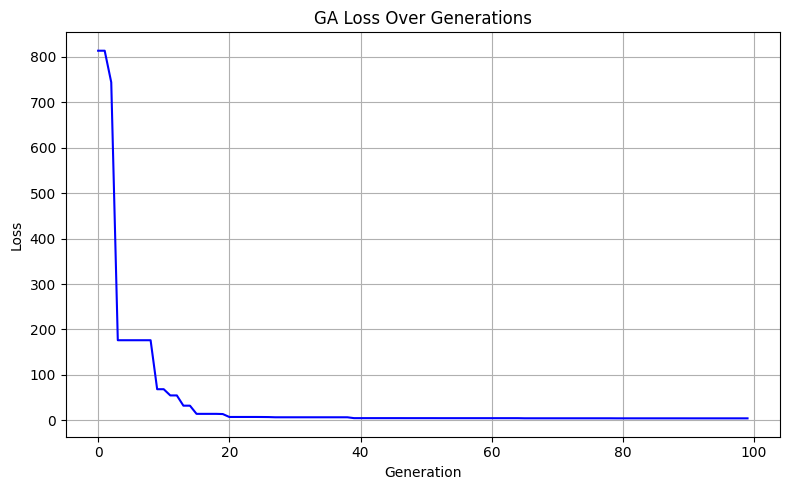

In [192]:
import matplotlib.pyplot as plt


def visualize_loss(losses_list):
    plt.figure(figsize=(8, 5))
    plt.plot(losses_list, linestyle="-", color="blue")
    plt.title("GA Loss Over Generations")
    plt.xlabel("Generation")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


losses_list = run_GA()
visualize_loss(losses_list)

In [193]:
# def visualize_predict_gt():
#   # visualization of ground truth and predict value
#   sorted_population = sorted(population, key=compute_fitness)
#   print(sorted_population[-1])
#   theta = np.array(sorted_population[-1])

#   estimated_prices = []
#   for feature in features_X:
#      # ************* your code here *************

#   fig, ax = plt.subplots(figsize=(10, 6))
#   plt.xlabel('Samples')
#   plt.ylabel('Price')
#   plt.plot(sales_Y, c='green', label='Real Prices')
#   plt.plot(estimated_prices, c='blue', label='Estimated Prices')
#   plt.legend()
#   plt.show()

# visualize_predict_gt()

[[np.float64(-1.6602552711556529), np.float64(-4.497823488607082), np.float64(-4.261357990410257), np.float64(-2.2984686016087097)], [np.float64(3.0186238175396807), np.float64(4.675398632843887), np.float64(4.42871188983079), np.float64(0.6231677536975866)], [np.float64(-0.7428833530534817), np.float64(4.9414130330282), np.float64(3.257508934656231), np.float64(-0.802061707730386)], [np.float64(-0.8373096398180102), np.float64(4.49057471736951), np.float64(0.24261493236058862), np.float64(3.8924960700508935)], [np.float64(-0.9215774730617621), np.float64(-4.661436242032816), np.float64(-2.4208049938031886), np.float64(0.016098636404355826)], [np.float64(4.868259347932514), np.float64(-4.859990112247333), np.float64(3.0076750807628185), np.float64(-2.915353124077763)], [np.float64(2.512613050972017), np.float64(-4.802293343577927), np.float64(-3.7998874919096695), np.float64(2.9887758481188795)], [np.float64(-1.35409312227745), np.float64(3.9906584534771508), np.float64(1.6778514989305

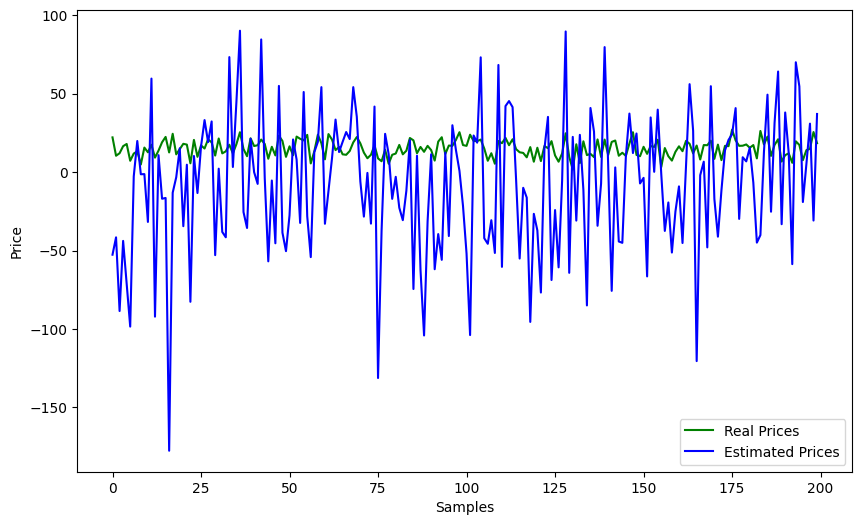

In [194]:
# visualization of ground truth and predict value
sorted_population = sorted(population, key=compute_fitness, reverse=False)
print(sorted_population)
theta = np.array(sorted_population[-1])

estimated_prices = []
samples = [i for i in range(len(features_X))]
for feature in features_X:
    estimated_price = sum(c*x for x, c in zip(feature, theta))
    print("Feature: ", feature)
    print("Theta: ", theta)
    print("Estimated price: ", estimated_price)
    estimated_prices.append(estimated_price)
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(sales_Y, c='green', label='Real Prices')
plt.plot(estimated_prices, c='blue', label='Estimated Prices')
plt.xlabel('Samples')
plt.ylabel('Price')
# plt.scatter(samples, sales_Y, c='green', label='Real Prices')
# plt.scatter(samples, estimated_prices, c='blue', label='Estimated Prices')
plt.legend()
plt.show()